<font size = "5"> **[Diffraction Tools](1_Diffraction_Tools.ipynb)** </font>

<hr style="height:2px;border-top:4px solid #FF8200" />


#  Kikuchi Map


[<img src=https://www.coeuscreativegroup.com/wp-content/uploads/2020/04/download-button.png, width=125>](https://raw.githubusercontent.com/pycroscopy/pyTEMlib/main/notebooks/Diffraction/D1_Diffraction_Rings.ipynb) 

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/pycroscopy/pyTEMlib/blob/main/notebooks/Diffraction/D1_Diffraction_Rings.ipynb)
    
    

part of 

<font size = "5"> **[pyTEMlib](https://pycroscopy.github.io/pyTEMlib/about.html)**</font>

a [pycroscopy](https://pycroscopy.github.io/pycroscopy/about.html) ecosystem package


Notebook by Gerd Duscher, 2026

Microscopy Facilities<br>
Institute of Advanced Materials & Manufacturing<br>
The University of Tennessee, Knoxville

Model based analysis and quantification of data acquired with transmission electron microscopes


## Content

An introduction into **diffraction_tools** and how to use the functions in this package to 
draw a map of Kikuchi bands.


An explanation on the physcial background can be found in the *Diffraction* chapter of MSE672-Introduction to TEM


## Install pyTEMlib

If you have not done so in the [Introduction Notebook](../0_pyTEMlib.ipynb), please test and install [pyTEMlib](https://github.com/pycroscopy/pyTEMlib) and other important packages with the code cell below.

You will have to run the code cell below every time in Google colab.
After that you need to restart the Runtime (in the Menu).

In [1]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test whether package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.06.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install git+https://github.com/pycroscopy/pyTEMlib.git@main -q --upgrade

print('done')

done


### Load the plotting and figure packages
Import the python packages that we will use:

Beside the basic numerical (numpy) and plotting (pylab of matplotlib) libraries,
* three dimensional plotting
and some libraries from the book
* kinematic scattering library from diffraction_tools in pyTEMlib.

In [ ]:
%matplotlib inline

import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../../')
import pyTEMlib
import pyTEMlib.diffraction_tools as dift
import pyTEMlib.crystal_tools as ct

print('pyTEMlib version', pyTEMlib.__version__)

pyTEMlib version 0.2026.9.0


## 1. Crystal and electron wavelength

The structure comes straight out of the `pyTEMlib` database, and the wavelength
from `get_wavelength`, which takes the unit we want to work in.

The experimental parameters need to be in the ase.Atoms datastructure in the atos.info dictionary under the key '\'experimental\''

We plot the map direcly with **pyTEMlib**.


Lattice(symbols='Si8', pbc=True, cell=[5.43088, 5.43088, 5.43088])
wavelength = 2.508 pm at 200 kV
190 allowed reflections with |g| <= 1.15 1/A
432 of 9968 random directions in the triangle (expect ~1/48 of z>0)
all three corners inside (the [111] corner sits on all three planes and needs the tolerance)

95 unique bands from 190 reflections
44 of 95 bands reach the drawn region (2.0 deg overscan)


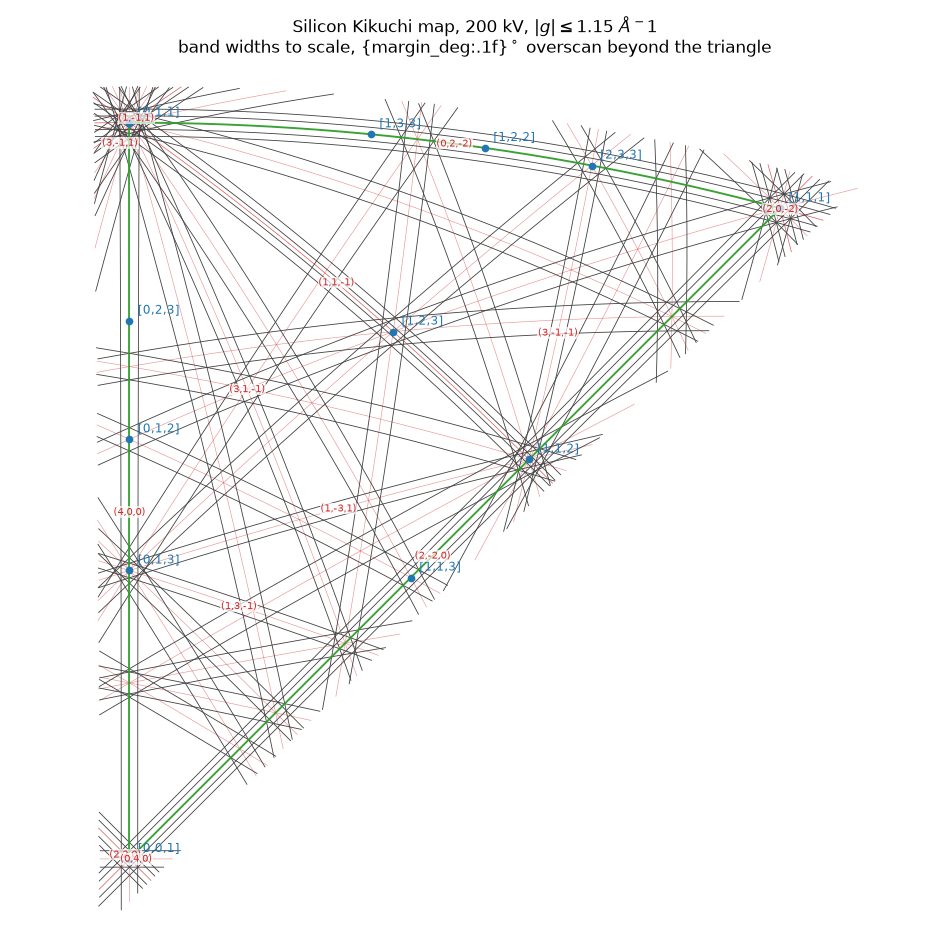

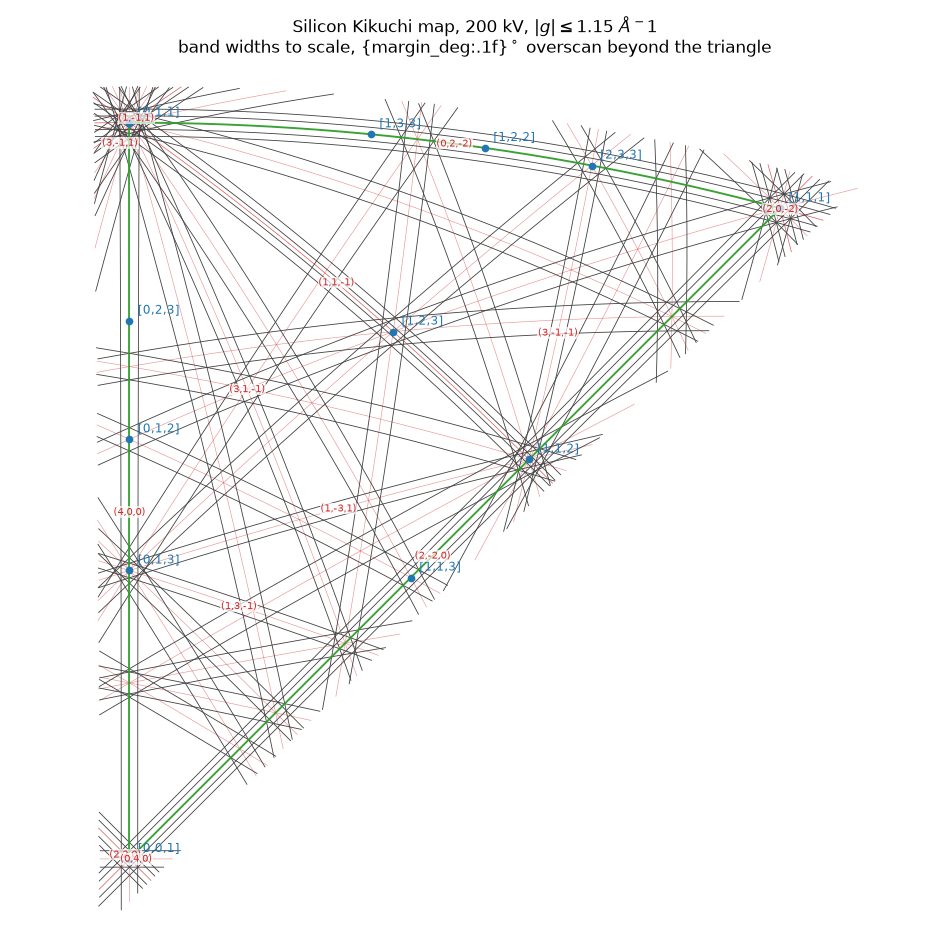

In [9]:
# ---------Input ----------
crystal = 'Silicon' #  'Iron', 'Silicon', 'Gold'
acceleration_voltage = 200 * 1000   # V  changes Kikuchi band width
g_max = 1.15   # 1/A  # adjust for number of Kikuchi lines
# -------------------------
atoms = pyTEMlib.crystal_tools.structure_by_name(crystal)
wavelength = pyTEMlib.diffraction_tools.get_wavelength(acceleration_voltage, unit='A')
atoms.info['experimental'] = {'acceleration_voltage': acceleration_voltage,
                            'wavelength': wavelength,
                            'g_max': g_max,
                            'hkl_max': int(np.ceil(g_max * atoms.cell.lengths()[0])) + 1}
atoms.info['name'] = crystal

print(atoms)
print(f"wavelength = {wavelength*100:.3f} pm at {acceleration_voltage / 1e3:.0f} kV")

fig, ax = pyTEMlib.diffraction_tools.draw_kikuchi_map(atoms)
fig.show()

## 2. Reciprocal lattice and allowed reflections

The metric tensor of the reciprocal lattice turns Miller indices into
$|\vec g|$ for **any** crystal system:

$$ |\vec g|^2 = (h\ k\ l)\; \mathbf{G}^{*} \begin{pmatrix} h \\ k \\ l\end{pmatrix} $$

A reflection is allowed when its structure factor does not vanish,

$$ F_{hkl} = \sum_j f^e_j(g)\, \exp\!\left(2\pi i\, \vec g \cdot \vec r_j \right) $$

with the atomic form factors $f^e_j(g)$.

All those reflections are calculated in `get_allowed_reflections`.

In [7]:

    
hkl, g, F = pyTEMlib.diffraction_tools.get_allowed_reflections(atoms)
zone_axes_to_consider = np.linalg.norm(g, axis=1)< g_max
len(zone_axes_to_consider)
reflections = hkl[zone_axes_to_consider]
g = g[zone_axes_to_consider]
structure_factor = F[zone_axes_to_consider]
g_length =  np.linalg.norm(g, axis=1)
print('%d allowed reflections with |g| <= %.2f 1/A' % (len(reflections), g_max))


190 allowed reflections with |g| <= 1.15 1/A


## 3. Stereographic projection and the standard triangle

A beam direction $\hat v$ in the upper hemisphere projects to

$$ (X, Y) = \left( \frac{v_x}{1 + v_z},\; \frac{v_y}{1 + v_z} \right) $$

The standard triangle with corners [001], [011], [111] is bounded by the three
planes $(100)$, $(1\bar 1 0)$ and $(0 1 \bar 1)$ - which are themselves the
centre lines of Kikuchi bands. A direction is inside when it lies on the
positive side of all three. The `margin` swings each plane outward by a true
angle so that bands sitting *on* the rim are drawn whole.

In [12]:
def normalize(v):
    v = np.atleast_2d(np.asarray(v, dtype=float))
    return v / np.linalg.norm(v, axis=1, keepdims=True)

def stereographic(v):
    v = normalize(v)
    return np.stack([v[:, 0] / (1 + v[:, 2]), v[:, 1] / (1 + v[:, 2])], axis=1)

# The three planes bounding the standard triangle.  Their normals are exactly
# the reflections whose bands run along the edges -- proven in section 5.
EDGE_NORMALS = normalize([[1, 0, 0], [-1, 1, 0], [0, -1, 1]])
EDGE_LABELS = ['(100)', '(-110)', '(0-11)']

def in_triangle(v, margin_deg=0.0, tol=1e-9):
    """Directions inside the standard triangle, optionally widened.

    ``margin_deg`` swings each bounding plane outward by that angle.  A band
    whose centre line runs *along* an edge then keeps both of its Bragg cones
    inside the drawn region instead of losing the outer one.  With
    ``margin_deg=0`` this is exactly the classic test 0 <= x <= y <= z.
    """
    v = normalize(v)
    limit = np.sin(np.radians(margin_deg)) + tol
    return (v @ EDGE_NORMALS.T >= -limit).all(axis=1)

# margin_deg=0 must reproduce the inequality form it replaces
_rng = np.random.default_rng(0)
_v = normalize(_rng.normal(size=(20000, 3)))
_v = _v[_v[:, 2] > 0]
_x, _y, _z = _v[:, 0], _v[:, 1], _v[:, 2]
_classic = (_x >= -1e-9) & (_x <= _y + 1e-9) & (_y <= _z + 1e-9)
assert (in_triangle(_v) == _classic).sum() >= len(_v) - 2, 'margin=0 must match 0<=x<=y<=z'
print('%d of %d random directions in the triangle (expect ~1/48 of z>0)'
      % (_classic.sum(), len(_v)))

corners = {'[001]': [0,0,1], '[011]': [0,1,1], '[111]': [1,1,1]}
for name, v in corners.items():
    assert in_triangle(v)[0], name
print('all three corners inside (the [111] corner sits on all three planes '
      'and needs the tolerance)\n')

def angle_between(u, v):
    u, v = normalize(u)[0], normalize(v)[0]
    return np.degrees(np.arccos(np.clip(u @ v, -1, 1)))

print('[001]-[011] %.4f deg' % angle_between([0,0,1], [0,1,1]))
print('[001]-[111] %.4f deg' % angle_between([0,0,1], [1,1,1]))
print('[011]-[111] %.4f deg' % angle_between([0,1,1], [1,1,1]))

432 of 9968 random directions in the triangle (expect ~1/48 of z>0)
all three corners inside (the [111] corner sits on all three planes and needs the tolerance)

[001]-[011] 45.0000 deg
[001]-[111] 54.7356 deg
[011]-[111] 35.2644 deg


## 4. The Kikuchi bands

A Kikuchi band for the reflection $(hkl)$ is the locus of beam directions that
satisfy the Bragg condition for that plane. Its centre line is the great circle
perpendicular to $\vec g$, and the two bright/dark edges are the Bragg cones at

$$ 90^\circ \pm \theta_B, \qquad \theta_B = \arcsin\!\left(\frac{\lambda |\vec g|}{2}\right) $$

so the **angular width of a band is $\Delta\theta = \lambda |\vec g|$**: wide bands
belong to large $|\vec g|$, i.e. to small lattice spacings.

In [ ]:

def cone_about(normal, alpha, n_points=4000):
    """Points on the unit sphere at angle *alpha* from *normal*."""
    n = normalize(normal)[0]
    tmp = np.array([0., 0., 1.]) if abs(n[2]) < 0.9 else np.array([1., 0., 0.])
    e1 = np.cross(n, tmp); e1 /= np.linalg.norm(e1)
    e2 = np.cross(n, e1)
    t = np.linspace(0, 2 * np.pi, n_points)
    return (np.cos(alpha) * n[None, :]
            + np.sin(alpha) * (np.cos(t)[:, None] * e1 + np.sin(t)[:, None] * e2))


def masked_projection(points, margin_deg=0.0):
    """Project, keeping only the upper hemisphere inside the (widened) triangle.

    Returns ``None`` when nothing survives.  Points outside become NaN so that
    matplotlib breaks the line rather than closing it across the figure.
    """
    points = np.atleast_2d(points)
    mask = in_triangle(points, margin_deg) & (points[:, 2] > 1e-9)
    if not mask.any():
        return None
    xy = stereographic(points)
    xy[~mask] = np.nan
    return xy


def unique_bands(reflections=None):
    """g and -g describe the same band; keep one representative of each."""
    seen = {}
    for index, hkl in enumerate(np.atleast_2d(reflections)):
        hkl = np.asarray(hkl, dtype=int)
        key = tuple(hkl if tuple(hkl) > tuple(-hkl) else -hkl)
        seen[key] = g_length[index]
    return seen


bands = unique_bands(reflections)
assert len(bands) * 2 == len(reflections), (len(bands), len(reflections))
print('%d unique bands from %d reflections' % (len(bands), len(reflections)))


207 unique bands from 414 reflections


## 5. The map

Band widths are **to scale** - no exaggeration factor. The widest band here is
about 1.6$^\circ$ across, so the lines are genuinely thin; that is what a Kikuchi
map looks like.

93 of 207 bands reach the drawn region (2.0 deg overscan)


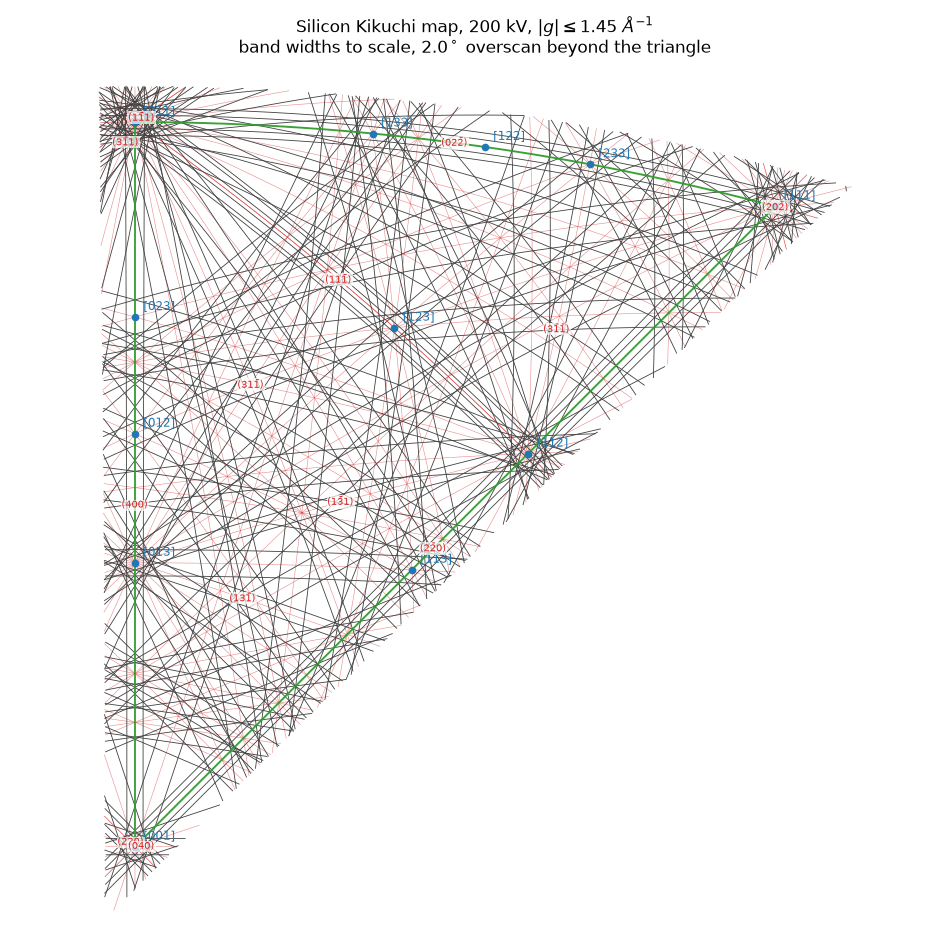

In [14]:
def bragg_angle(g):
    return np.arcsin(np.clip(wavelength * np.asarray(g) / 2.0, -1, 1))
def pretty_plain(hkl):
    """Plain-text (no mathtext) index label, safe in titles and print()."""
    return '[' + ','.join('%d' % i for i in np.asarray(hkl).astype(int)) + ']'

from matplotlib import mathtext as _mathtext
_MATH_PARSER = _mathtext.MathTextParser('agg')


def mathtext_ok(label):
    """True if *label* can be parsed by matplotlib's mathtext engine."""
    try:
        _MATH_PARSER.parse(label, 100, None)
        return True
    except Exception:
        return False


def pretty(hkl, brackets='()'):
    """Mathtext label for a Miller index triple, negatives as overbars.

    Built locally rather than with ``dift.make_pretty_labels``: that helper
    returns a string with unbalanced braces and an interior '$', which makes
    matplotlib raise a mathtext ParseException as soon as the text extent is
    needed (e.g. inside plt.tight_layout).  Indices with two or more digits
    are comma separated so that e.g. (1,10,2) is not confused with (1,1,0,2).
    """
    idx = np.asarray(hkl).astype(int)
    parts = [(r'\bar{%d}' % -i) if i < 0 else ('%d' % i) for i in idx]
    sep = ',' if np.abs(idx).max() > 9 else ''
    label = '$%s%s%s$' % (brackets[0], sep.join(parts), brackets[1])
    if not mathtext_ok(label):                      # last-resort plain text
        label = '%s%s%s' % (brackets[0], ','.join('%d' % i for i in idx), brackets[1])
    return label


MARGIN_DEG = 2.0        # how far outside the triangle the map is drawn

POLES = [[0,0,1],[0,1,1],[1,1,1],[0,1,2],[1,1,2],[1,2,2],
         [0,1,3],[1,1,3],[0,2,3],[1,2,3],[1,3,3],[2,3,3]]


def triangle_outline(n=400):
    """The three edges of the strict triangle, as great-circle arcs."""
    arcs = []
    keys = list(corners.values())
    for p, q in [(keys[0], keys[1]), (keys[1], keys[2]), (keys[2], keys[0])]:
        p, q = normalize(p)[0], normalize(q)[0]
        t = np.linspace(0, 1, n)[:, None]
        arc = normalize(p[None, :] * (1 - t) + q[None, :] * t)
        arcs.append(stereographic(arc))
    return arcs


def kikuchi_map(bands, margin_deg=MARGIN_DEG, label_bands=True,
                figsize=(9.5, 9.5), ax=None):
    """Draw the map, overscanning *margin_deg* beyond the triangle edges.

    Each Bragg cone is clipped independently: a band whose centre line runs
    along an edge keeps its outer cone, which the strict mask threw away.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    n_drawn = 0
    extent = []
    for hkl, g in sorted(bands.items(), key=lambda kv: kv[1]):
        theta = bragg_angle(g)
        pieces = []
        for alpha in (np.pi/2 - theta, np.pi/2 + theta):
            xy = masked_projection(cone_about(hkl, alpha), margin_deg)
            if xy is not None:
                pieces.append(xy)
        mid = masked_projection(cone_about(hkl, np.pi/2), margin_deg)
        if not pieces and mid is None:
            continue
        n_drawn += 1
        for xy in pieces:
            ax.plot(xy[:, 0], xy[:, 1], lw=0.6, color='0.25',
                    solid_capstyle='butt', zorder=2)
            extent.append(xy)
        if mid is not None:
            ax.plot(mid[:, 0], mid[:, 1], lw=0.4, color='tab:red',
                    alpha=0.55, zorder=1)
            extent.append(mid)
            if label_bands and g < 0.75:
                ok = np.where(~np.isnan(mid[:, 0]))[0]
                p = mid[ok[len(ok) // 2]]
                ax.annotate(pretty(hkl), p, fontsize=7, color='tab:red',
                            ha='center', va='center', zorder=6,
                            bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.4))

    for arc in triangle_outline():
        ax.plot(arc[:, 0], arc[:, 1], lw=1.4, color='tab:green',
                alpha=0.9, zorder=4)

    for v in POLES:
        if not in_triangle(v)[0]:
            continue
        p = stereographic(v)[0]
        ax.plot(*p, 'o', ms=4.5, color='tab:blue', zorder=5)
        ax.annotate(pretty(v, '[]'), p, textcoords='offset points',
                    xytext=(6, 5), fontsize=8.5, color='tab:blue', zorder=5)

    # frame from what was actually drawn, so the overscan is never cut off
    xy = np.vstack(extent)
    x0, y0 = np.nanmin(xy, axis=0)
    x1, y1 = np.nanmax(xy, axis=0)
    pad = 0.03 * max(x1 - x0, y1 - y0)
    ax.set_xlim(x0 - pad, x1 + pad)
    ax.set_ylim(y0 - pad, y1 + pad)

    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title('Silicon Kikuchi map, %.0f kV, $|g| \\leq %.2f\\ \\AA^{-1}$'
                 '\nband widths to scale, %.1f$^\\circ$ overscan beyond the triangle'
                 % (acceleration_voltage / 1e3, g_max, margin_deg))
    print('%d of %d bands reach the drawn region (%.1f deg overscan)'
          % (n_drawn, len(bands), margin_deg))
    return fig, ax

fig, ax = kikuchi_map(bands)
plt.tight_layout()
plt.show()

In [2]:
MARGIN_DEG = 2  # degrees

def basis_perp(n_hat):
    tmp = np.array([1.,0.,0.]) if abs(n_hat[0]) < 0.9 else np.array([0.,1.,0.])
    e1 = np.cross(n_hat, tmp); e1 /= np.linalg.norm(e1)
    e2 = np.cross(n_hat, e1)
    return e1, e2

def point_on_cone(n_hat, alpha, t):
    e1, e2 = basis_perp(n_hat)
    return np.cos(alpha)*n_hat + np.sin(alpha)*(np.cos(t)*e1 + np.sin(t)*e2)

def analytic_circle(n_hat, d):
    """Stereographic image of {v : v.n_hat = d} on the unit sphere.
    Returns (cx, cy, r) or None if it projects to a line (c + d == 0)."""
    a, b, c = n_hat
    if abs(c + d) < 1e-9:
        return None
    cx, cy = a/(c+d), b/(c+d)
    r = np.sqrt(max(1 - d**2, 0.0)) / abs(c+d)
    return cx, cy, r

def find_arcs(n_hat, alpha, margin_deg=MARGIN_DEG, n_scan=720):
    """Angular sub-intervals of t in [0, 2pi) where point_on_cone is inside
    the triangle (plus margin). Boundaries refined by bisection."""
    n_hat = n_hat/np.linalg.norm(n_hat)
    margin = np.radians(margin_deg)
    ts = np.linspace(0, 2*np.pi, n_scan, endpoint=False)
    vals = np.array([membership(point_on_cone(n_hat,alpha,t), margin) for t in ts])
    inside = vals >= 0
    if inside.all():
        return [(0.0, 2*np.pi)]
    if not inside.any():
        return []
    idx = np.where(inside != np.roll(inside, 1))[0]
    roots = []
    for i in idx:
        t0, t1 = ts[i-1], ts[i]
        f0 = membership(point_on_cone(n_hat,alpha,t0), margin)
        for _ in range(50):
            tm = 0.5*(t0+t1)
            fm = membership(point_on_cone(n_hat,alpha,tm), margin)
            if np.sign(fm) == np.sign(f0):
                t0, f0 = tm, fm
            else:
                t1 = tm
        roots.append(0.5*(t0+t1))
    roots = sorted(roots)
    arcs = []
    for k in range(len(roots)):
        ta, tb = roots[k], roots[(k+1) % len(roots)]
        tmid = ta + ((tb - ta) % (2*np.pi))/2
        if membership(point_on_cone(n_hat,alpha,tmid), margin) >= 0:
            arcs.append((ta, tb))
    return arcs

def draw_band_edge(ax, n_hat, alpha, lw, color, margin_deg=MARGIN_DEG):
    """Draw the stereographic image of one Bragg cone as exact Arc patch(es)."""
    n_hat = n_hat/np.linalg.norm(n_hat)
    d = np.cos(alpha)
    circ = analytic_circle(n_hat, d)
    arcs = find_arcs(n_hat, alpha, margin_deg)
    n_drawn = 0
    for ta, tb in arcs:
        if circ is None:
            # degenerate: draw as a short straight segment (rare, axis-dependent)
            n_line = 40
            tt = np.linspace(ta, tb, n_line) if tb > ta else \
                 np.linspace(ta, tb + 2*np.pi, n_line)
            pts = np.array([point_on_cone(n_hat, alpha, t) for t in tt])
            u, w = stereo(pts)
            ax.plot(u, w, color=color, lw=lw, solid_capstyle='round')
        else:
            cx, cy, r = circ
            pa = stereo(point_on_cone(n_hat, alpha, ta))
            pb = stereo(point_on_cone(n_hat, alpha, tb))
            phi_a = np.degrees(np.arctan2(pa[1]-cy, pa[0]-cx)) % 360
            phi_b = np.degrees(np.arctan2(pb[1]-cy, pb[0]-cx)) % 360
            # Arc draws counter-clockwise from theta1 to theta2; ensure correct
            # sweep by checking the arc midpoint matches our intended interval
            tmid = ta + ((tb - ta) % (2*np.pi))/2
            mid3d = point_on_cone(n_hat, alpha, tmid)
            mu, mw = stereo(mid3d)
            phi_mid_expected = np.degrees(np.arctan2(mw-cy, mu-cx)) % 360
            theta1, theta2 = phi_a, phi_b
            if theta2 < theta1:
                theta2 += 360
            sweep_mid = (theta1 + ((theta2-theta1) % 360)/2) % 360
            if abs(((sweep_mid - phi_mid_expected + 180) % 360) - 180) > 1.0:
                theta1, theta2 = phi_b, phi_a
                if theta2 < theta1:
                    theta2 += 360
            ax.add_patch(Arc((cx,cy), 2*r, 2*r, angle=0,
                              theta1=theta1, theta2=theta2,
                              color=color, lw=lw, capstyle='round'))
        n_drawn += 1
    return n_drawn

In [3]:
test_g = np.array([1.,1.,1.])/np.sqrt(3)
theta_B_test = np.radians(0.4)
arcs = find_arcs(test_g, np.pi/2 - theta_B_test)
circ = analytic_circle(test_g, np.cos(np.pi/2 - theta_B_test))
assert len(arcs) >= 1
ta, tb = arcs[0]
for t in (ta, tb):
    m = membership(point_on_cone(test_g, np.pi/2-theta_B_test, t), np.radians(MARGIN_DEG))
    assert abs(m) < 1e-6, m
cx, cy, r = circ
pa = stereo(point_on_cone(test_g, np.pi/2-theta_B_test, ta))
assert abs(np.hypot(pa[0]-cx, pa[1]-cy) - r) < 1e-9
print('arc endpoints lie on the triangle boundary and on the analytic circle (OK)')

NameError: name 'np' is not defined

## 6. How the map changes with voltage

Since $\Delta\theta = \lambda |\vec g|$, the bands narrow as the electrons get
faster. This is why Kikuchi patterns are easier to see and to use at 80-120 kV
than at 300 kV.

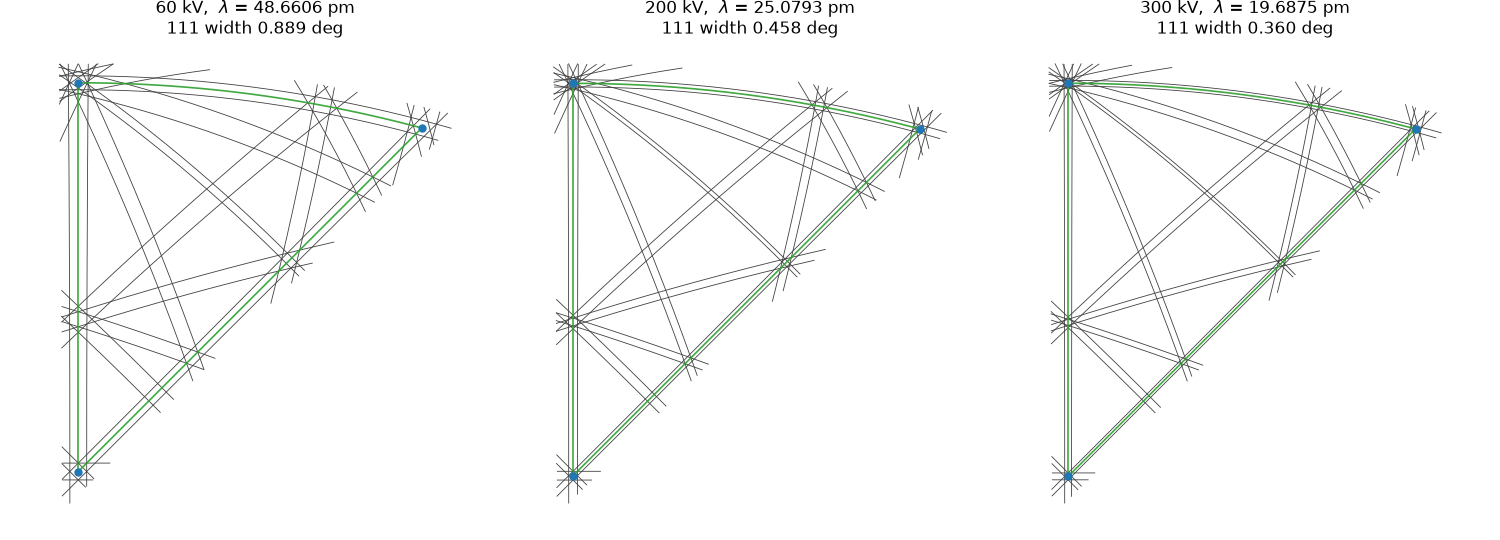

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax_i, kV in zip(axes, [60, 200, 300]):
    lam_kV = pyTEMlib.diffraction_tools.get_wavelength(kV * 1e3, unit='A')
    for hkl, g in sorted(bands.items(), key=lambda kv: kv[1])[:40]:
        th = np.arcsin(np.clip(lam_kV * g / 2, -1, 1))
        for alpha in (np.pi/2 - th, np.pi/2 + th):
            xy = masked_projection(cone_about(hkl, alpha), MARGIN_DEG)
            if xy is None:
                continue
            ax_i.plot(xy[:, 0], xy[:, 1], lw=0.6, color='0.25')
    for arc in triangle_outline():
        ax_i.plot(arc[:, 0], arc[:, 1], lw=1.2, color='tab:green', alpha=0.9)
    for v in [[0,0,1],[0,1,1],[1,1,1]]:
        ax_i.plot(*stereographic(v)[0], 'o', ms=5, color='tab:blue')
    ax_i.set_aspect('equal'); ax_i.axis('off')
    width_111 = np.degrees(lam_kV *g_length[np.where(np.all(reflections ==[1.,1.,1.], axis=1) )[0]])[0]
    ax_i.set_title(f"{kV:d} kV,  $\\lambda$ = {lam_kV*1000:.4f} pm\n{111} width {width_111:.3f} deg")
    #               % (kV, lam_kV)) # , np.degrees(lam_kV * g_length((1,1,1))[0])))
plt.tight_layout(); plt.show()

## 7. Tilting from [001] to [111]

The edge [001]-[111] of the triangle *is* the centre line of the
$(1\bar 1 0)$ band. Tilting along it walks through the poles [114], [113],
[112], [223] - which is exactly how one drives the goniometer from one
low-index zone axis to the next.

In [16]:
path = [[0,0,1],[1,1,4],[1,1,3],[1,1,2],[2,2,3],[1,1,1]]
n = normalize([1,-1,0])[0]

total = 0.0
for p, q in zip(path[:-1], path[1:]):
    step = angle_between(p, q)
    total += step
    print('[%d%d%d] -> [%d%d%d]  %7.4f deg   |g.u| = %.1e'
          % (*p, *q, step, abs(normalize(q)[0] @ n)))

direct = angle_between(path[0], path[-1])
print('\nsum of legs %.4f deg   direct %.4f deg' % (total, direct))
assert abs(total - direct) < 1e-6


[001] -> [114]  19.4712 deg   |g.u| = 0.0e+00
[114] -> [113]   5.7682 deg   |g.u| = 0.0e+00
[113] -> [112]  10.0250 deg   |g.u| = 0.0e+00
[112] -> [223]   8.0495 deg   |g.u| = 0.0e+00
[223] -> [111]  11.4218 deg   |g.u| = 0.0e+00

sum of legs 54.7356 deg   direct 54.7356 deg
